# Customer Intelligence System — Country Development Segmentation

**Dataset:** `Country-data.csv` — 167 countries, 9 socio-economic/health indicators,
no target column. (`data-dictionary.csv` describes each column if you need it.)

**Problem statement.** An NGO (or any organization allocating resources across countries)
needs to know *which countries need help most*, without a pre-existing label for
"development tier." We treat each country as an entity/segment, the same way a business
would treat customers: we don't know the segments in advance, so we (1) **discover** them
with clustering, then (2) **operationalize** them by training a classifier that can score
*any* country — including ones outside this dataset, or countries whose stats get updated
next year — without re-running the clustering.

**Pipeline** (all of it runs in this one notebook, top to bottom):
```
Country-data.csv
      │
      ▼
[1] EDA & Cleaning ─── nulls/duplicates check, outlier audit, skew check → log1p(income, gdpp)
      │
      ▼
[2] Clustering (unsupervised) ── StandardScaler → KMeans (elbow+silhouette) vs DBSCAN (k-distance)
      │                          → PCA(2D) for visualization → label clusters (Needs Aid / Developing / Developed)
      ▼
[3] Classification (supervised) ── target = cluster label
      │   Logistic Regression (baseline) · Random Forest (tuned) · XGBoost (tuned)
      │   5-fold stratified CV + held-out test · macro-F1, confusion matrix, feature importance
      ▼
[4] Model comparison table ── pick a winner
      ▼
[5] predict_segment(...) — score any new country from its 9 raw indicators
```

Just run every cell top to bottom (Kernel → Restart & Run All). Only requirement: keep
`Country-data.csv` in the same folder as this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV,
)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 12)

RANDOM_STATE = 42
FEATURE_COLUMNS = [
    "child_mort", "exports", "health", "imports",
    "income", "inflation", "life_expec", "total_fer", "gdpp",
]
LOG_TRANSFORM_CANDIDATES = ["income", "gdpp"]

print("Feature columns:", FEATURE_COLUMNS)
print(f"XGBoost installed in this environment: {XGBOOST_AVAILABLE}")

Feature columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
XGBoost installed in this environment: False


## 1. EDA & Cleaning

Load the raw data, check it's actually clean (nulls/duplicates), audit outliers without
blindly dropping them (they're real countries), and decide — based on measured skew, not
assumption — which features get a log transform before scaling.

In [2]:
df = pd.read_csv("Country-data.csv")
print(df.shape)
df.head()

(167, 10)


In [3]:
print(df.head(8).to_string(index=False))

            country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp
        Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82   553
            Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65  4090
            Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89  4460
             Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16  3530
Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13 12200
          Argentina        14.5     18.9    8.10     16.0   18700      20.90        75.8       2.37 10300
            Armenia        18.1     20.8    4.40     45.3    6700       7.77        73.3       1.69  3220
          Australia         4.8     19.8    8.73     20.9   41400       1.16        82.0       1.93 51900


In [4]:
n_dup_rows = int(df.duplicated().sum())
n_dup_countries = int(df["country"].duplicated().sum())
n_nulls = int(df.isnull().sum().sum())
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")
print(f"Duplicate rows: {n_dup_rows}")
print(f"Duplicate country names: {n_dup_countries}")
print(f"Total nulls: {n_nulls}")

Rows: 167, Columns: 10
Duplicate rows: 0
Duplicate country names: 0
Total nulls: 0


Clean: no nulls, no duplicate rows or countries. Nothing to impute or drop on that front.

In [5]:
def iqr_outlier_report(data, columns, multiplier=1.5):
    rows = []
    for col in columns:
        q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
        n_out = int(((data[col] < lower) | (data[col] > upper)).sum())
        rows.append({"feature": col, "lower_bound": lower, "upper_bound": upper, "n_outliers": n_out})
    return pd.DataFrame(rows)

outliers = iqr_outlier_report(df, FEATURE_COLUMNS)
print(outliers.to_string(index=False))

   feature  lower_bound  upper_bound  n_outliers
child_mort     -72.5250     142.8750           4
   exports     -17.5250      92.6750           5
    health      -0.6000      14.1200           2
   imports     -12.6250     101.5750           4
    income  -25812.5000   51967.5000           8
 inflation     -11.6000      24.1600           5
life_expec      48.0500      94.0500           3
 total_fer      -1.3325       7.0075           1
      gdpp  -17750.0000   33130.0000          25


Every feature has IQR outliers — expected for country-level data (a handful of very poor
or very rich countries pull the tails). We keep every row: these "outliers" are exactly
the extreme cases a Needs-Aid/Developed segmentation exists to separate. Dropping them
would remove the signal, not noise.

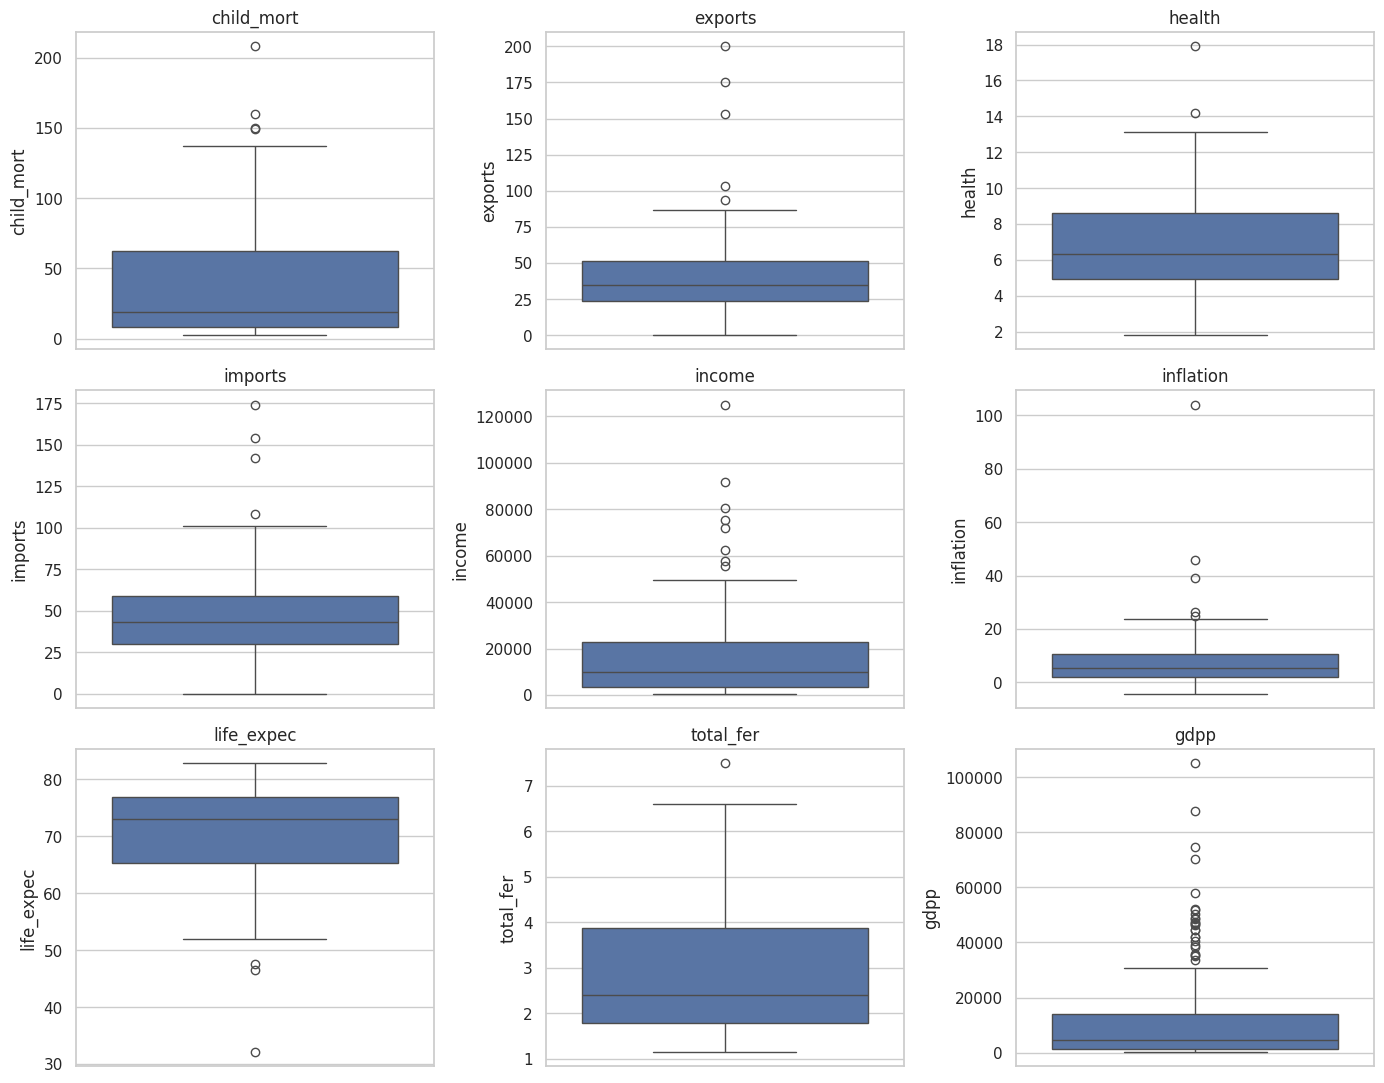

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()

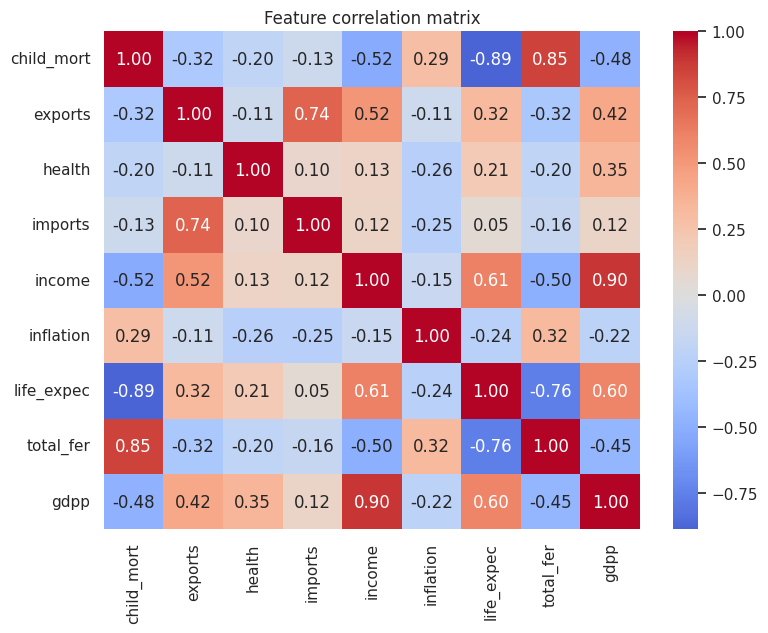

In [7]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()

`income` and `gdpp` are strongly correlated (both measure economic output per person),
as are `imports`/`exports`. `child_mort` and `life_expec` are strongly *negatively*
correlated, as expected. None of this is surprising, but it's worth confirming before
clustering on all 9 features — highly correlated features implicitly get double weight
in a Euclidean-distance method like KMeans.

In [8]:
skew = df[FEATURE_COLUMNS].skew().rename("skew").reset_index().rename(columns={"index": "feature"})
skew["needs_log_transform"] = skew["skew"].abs() > 1.0
skew = skew.sort_values("skew", ascending=False).reset_index(drop=True)
print(skew.to_string(index=False))

   feature      skew  needs_log_transform
 inflation  5.154049                 True
   exports  2.445824                 True
    income  2.231480                 True
      gdpp  2.218051                 True
   imports  1.905276                 True
child_mort  1.450774                 True
 total_fer  0.967092                False
    health  0.705746                False
life_expec -0.970996                False


In [9]:
flagged_by_skew = skew.loc[skew["needs_log_transform"], "feature"].tolist()
print(f"Flagged by |skew| > 1: {flagged_by_skew}")
print(f"Actually log-transformed: {LOG_TRANSFORM_CANDIDATES}")
print()
print(
    f"{len(flagged_by_skew)} features cross |skew|>1, but only {LOG_TRANSFORM_CANDIDATES} are "
    "log-transformed. income and gdpp are per-capita monetary values spanning roughly two "
    "orders of magnitude (a few hundred dollars up to $100k+) — the textbook case for a log "
    "transform, since it's their multiplicative (not additive) differences that are "
    "meaningful. The other flagged columns (exports, imports, inflation, child_mort) are "
    "already rates or %-of-GDP figures on a comparable, bounded scale; log-transforming them "
    "would mostly just compress real variance (e.g. very high child mortality in a handful of "
    "countries is a genuine, meaningful outlier, not an artifact of scale) without the same "
    "justification. StandardScaler still applies to all 9 features afterward, which handles "
    "the remaining scale differences for distance-based methods."
)

Flagged by |skew| > 1: ['inflation', 'exports', 'income', 'gdpp', 'imports', 'child_mort']
Actually log-transformed: ['income', 'gdpp']

6 features cross |skew|>1, but only ['income', 'gdpp'] are log-transformed. income and gdpp are per-capita monetary values spanning roughly two orders of magnitude (a few hundred dollars up to $100k+) — the textbook case for a log transform, since it's their multiplicative (not additive) differences that are meaningful. The other flagged columns (exports, imports, inflation, child_mort) are already rates or %-of-GDP figures on a comparable, bounded scale; log-transforming them would mostly just compress real variance (e.g. very high child mortality in a handful of countries is a genuine, meaningful outlier, not an artifact of scale) without the same justification. StandardScaler still applies to all 9 features afterward, which handles the remaining scale differences for distance-based methods.


**Decision:** only `income` and `gdpp` get `log1p`'d, even though 4 other columns also
cross the |skew|>1 threshold, for the reasons printed above.

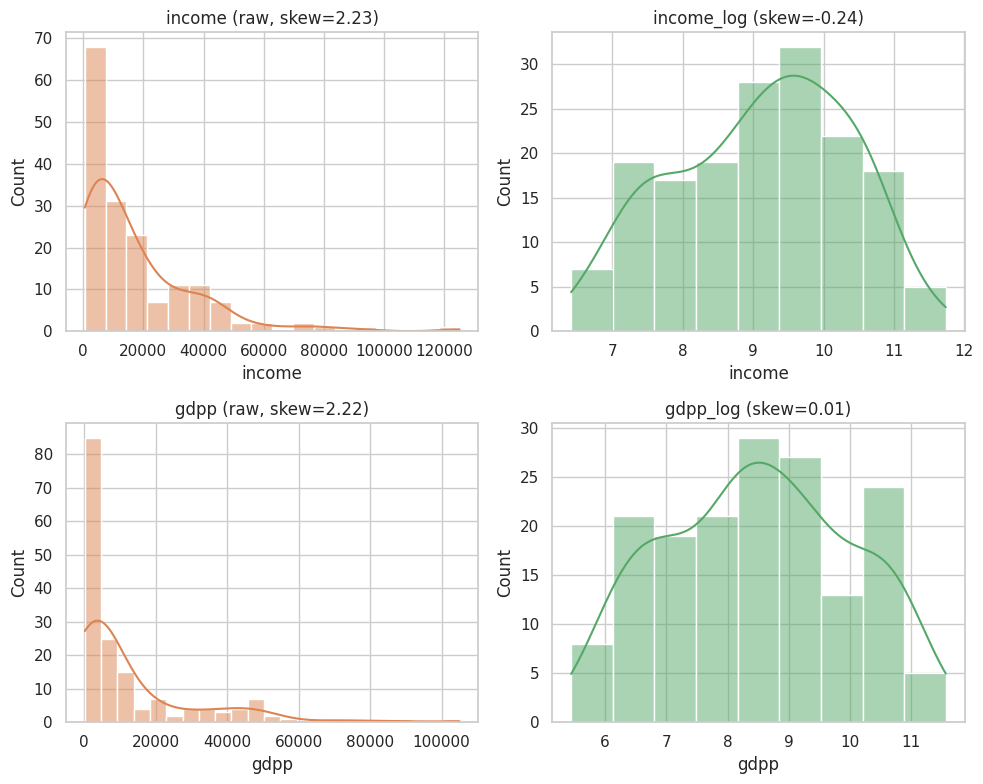

In [10]:
fig, axes = plt.subplots(len(LOG_TRANSFORM_CANDIDATES), 2, figsize=(10, 4 * len(LOG_TRANSFORM_CANDIDATES)))
for i, col in enumerate(LOG_TRANSFORM_CANDIDATES):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="#DD8452")
    axes[i, 0].set_title(f"{col} (raw, skew={df[col].skew():.2f})")
    logged = np.log1p(df[col])
    sns.histplot(logged, kde=True, ax=axes[i, 1], color="#55A868")
    axes[i, 1].set_title(f"{col}_log (skew={logged.skew():.2f})")
plt.tight_layout()

## 2. Clustering — generating the labels

No target exists, so this stage manufactures one. `StandardScaler` first, then KMeans
(elbow + silhouette to pick k) compared against DBSCAN (eps/min_samples tuned from a
k-distance plot), visualized in 2D with PCA, then the winning clustering is labeled using
the 4 features that actually define "development": `gdpp`, `income`, `child_mort`,
`life_expec`.

In [11]:
model_matrix = df.copy()
for col in LOG_TRANSFORM_CANDIDATES:
    model_matrix[col] = np.log1p(model_matrix[col])
model_matrix = model_matrix[FEATURE_COLUMNS]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(model_matrix), columns=FEATURE_COLUMNS, index=df.index)
X_scaled.head(3)

In [12]:
rows, km_fits = [], {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})
    km_fits[k] = km
km_selection = pd.DataFrame(rows)
print("KMeans model selection (k=2..10):")
print(km_selection.to_string(index=False))

KMeans model selection (k=2..10):
 k    inertia  silhouette
 2 944.464093    0.358075
 3 792.227081    0.236340
 4 671.695694    0.249352
 5 587.869123    0.257246
 6 538.452574    0.237603
 7 472.528130    0.250058
 8 431.102540    0.221446
 9 397.724720    0.218074
10 375.687994    0.233092


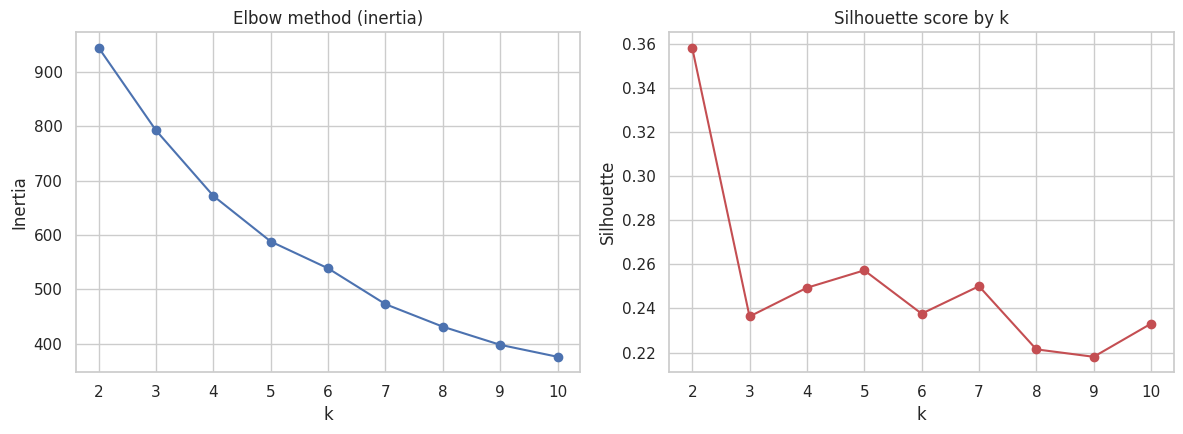

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(km_selection["k"], km_selection["inertia"], marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(km_selection["k"], km_selection["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()

Silhouette alone barely distinguishes k=3 from k=4 here (0.236 vs 0.249 — well within
noise for n=167). We don't pick k by silhouette alone: **any k whose smallest cluster
falls under 10% of the data is disqualified first.** Checked directly: k=4 splits off a
5-country cluster (Luxembourg, Ireland, Singapore, Malta, Seychelles) whose common thread
turns out to be extreme exports/imports-as-%-of-GDP (small, trade-hub economies), not a
wealth tier — mixing e.g. Seychelles (gdpp \$10.8k) with Luxembourg (gdpp \$105k) in one
"segment." That fragments the ordinal Needs-Aid → Developing → Developed story instead of
refining it, and a 5-country segment is also too small to classify reliably later. k=3
passes the size guard and produces three clusters that are each internally coherent on
gdpp/income/child_mort/life_expec — that's the one we use.

In [14]:
min_cluster_frac = 0.10
qualifying_k = [k for k in [3, 4] if pd.Series(km_fits[k].labels_).value_counts().min() / len(df) >= min_cluster_frac]
candidate_range = km_selection[km_selection["k"].isin(qualifying_k or [3, 4])]
best_k = int(candidate_range.loc[candidate_range["silhouette"].idxmax(), "k"])
kmeans_model = km_fits[best_k]
km_silhouette = float(km_selection.loc[km_selection["k"] == best_k, "silhouette"].values[0])
print(f"Chosen k = {best_k}  (silhouette = {km_silhouette:.3f})")

Chosen k = 3  (silhouette = 0.236)


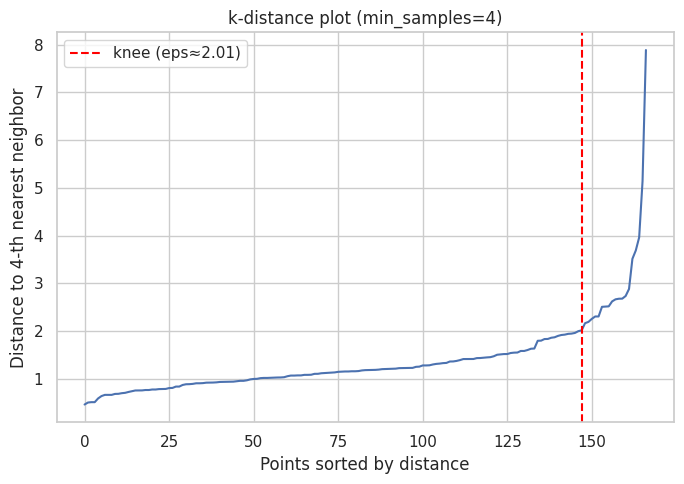

In [15]:
def k_distance_values(data, min_samples):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(data)
    distances, _ = nn.kneighbors(data)
    return np.sort(distances[:, -1])

def find_knee(sorted_values):
    n = len(sorted_values)
    x = np.arange(n)
    y = sorted_values
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line_vec = (p2 - p1) / np.linalg.norm(p2 - p1)
    dists = [np.linalg.norm(np.array([x[i], y[i]]) - (p1 + np.dot(np.array([x[i], y[i]]) - p1, line_vec) * line_vec))
             for i in range(n)]
    return int(np.argmax(dists))

kth_for_plot = k_distance_values(X_scaled, min_samples=best_k + 1)
knee_idx = find_knee(kth_for_plot)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(kth_for_plot)
ax.axvline(knee_idx, color="red", linestyle="--", label=f"knee (eps≈{kth_for_plot[knee_idx]:.2f})")
ax.set_title(f"k-distance plot (min_samples={best_k + 1})")
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {best_k + 1}-th nearest neighbor")
ax.legend()
plt.tight_layout()

In [16]:
def dbscan_grid_search(data, min_samples_range=(4, 5, 6, 8, 10), max_noise_frac=0.3):
    rows, fits = [], {}
    for ms in min_samples_range:
        kth = k_distance_values(data, ms)
        knee_eps = kth[find_knee(kth)]
        eps_candidates = knee_eps * np.array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1])
        best = None
        for eps in eps_candidates:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = int((labels == -1).sum())
            noise_frac = n_noise / len(labels)
            if 2 <= n_clusters <= 6 and noise_frac < max_noise_frac:
                mask = labels != -1
                sil = silhouette_score(data[mask], labels[mask])
                if best is None or sil > best["silhouette_non_noise"]:
                    best = {"min_samples": ms, "eps": round(float(eps), 3), "n_clusters": n_clusters,
                            "n_noise": n_noise, "silhouette_non_noise": sil}
                    fits[ms] = (db, labels)
        if best is None:
            db = DBSCAN(eps=knee_eps, min_samples=ms)
            labels = db.fit_predict(data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            best = {"min_samples": ms, "eps": round(float(knee_eps), 3), "n_clusters": n_clusters,
                    "n_noise": int((labels == -1).sum()), "silhouette_non_noise": np.nan}
            fits[ms] = (db, labels)
        rows.append(best)
    return pd.DataFrame(rows), fits

db_results, db_fits = dbscan_grid_search(X_scaled.values)
print("DBSCAN grid search (eps tuned per min_samples from the k-distance knee):")
print(db_results.to_string(index=False))

DBSCAN grid search (eps tuned per min_samples from the k-distance knee):
 min_samples   eps  n_clusters  n_noise  silhouette_non_noise
           4 1.409           2       36              0.455463
           5 1.439           2       33              0.457100
           6 2.136           1       11                   NaN
           8 2.263           1       11                   NaN
          10 2.725           1        5                   NaN


In [17]:
valid = db_results.dropna(subset=["silhouette_non_noise"])
multi_seg = valid[valid["n_clusters"] >= 3]
comparable_to_kmeans = len(multi_seg) > 0
pool = multi_seg if comparable_to_kmeans else valid

if len(pool) > 0:
    best_db_row = pool.loc[pool["silhouette_non_noise"].idxmax()]
    best_ms = int(best_db_row["min_samples"])
    db_model, db_labels = db_fits[best_ms]
    db_silhouette = float(best_db_row["silhouette_non_noise"])
    db_n_clusters = int(best_db_row["n_clusters"])
else:
    best_ms, db_labels, db_silhouette, db_n_clusters = None, None, np.nan, None

noise_frac = (db_labels == -1).sum() / len(db_labels) if db_labels is not None else None
use_dbscan = (comparable_to_kmeans and not np.isnan(db_silhouette)
              and db_silhouette > km_silhouette + 0.05 and noise_frac is not None and noise_frac < 0.15)

if not comparable_to_kmeans and db_labels is not None:
    decision_note = (
        f"DBSCAN never finds a stable {best_k}-segment structure across the tuned "
        f"min_samples/eps grid: it either collapses everything into 1 cluster, or, at best, "
        f"recovers a coarse 2-cluster split (silhouette={db_silhouette:.3f}, {noise_frac:.0%} "
        f"noise) driven mostly by the income/gdpp scale gap. That's not comparable to KMeans' "
        f"{best_k}-segment silhouette ({km_silhouette:.3f}) since fewer clusters inflate "
        f"silhouette regardless of quality. KMeans is canonical: it's the only method that "
        f"delivers the requested multi-tier segmentation with every country assigned a segment."
    )
else:
    decision_note = (
        f"At matched granularity ({db_n_clusters} segments), KMeans silhouette={km_silhouette:.3f} "
        f"vs DBSCAN silhouette={db_silhouette:.3f} ({noise_frac:.0%} noise). "
        + ("DBSCAN wins clearly with limited noise, so it is used as canonical." if use_dbscan else
           "KMeans is used as canonical: DBSCAN doesn't clearly win and, unlike DBSCAN, assigns "
           "every country a segment with no unstable noise class.")
    )
print(decision_note)

DBSCAN never finds a stable 3-segment structure across the tuned min_samples/eps grid: it either collapses everything into 1 cluster, or, at best, recovers a coarse 2-cluster split (silhouette=0.457, 20% noise) driven mostly by the income/gdpp scale gap. That's not comparable to KMeans' 3-segment silhouette (0.236) since fewer clusters inflate silhouette regardless of quality. KMeans is canonical: it's the only method that delivers the requested multi-tier segmentation with every country assigned a segment.


**Canonical labeling: KMeans.** Countries here sit on a continuous socio-economic
gradient rather than in density-separated blobs, so DBSCAN's best multi-segment
attempt collapses to a coarse 2-cluster split with real noise, or to one giant cluster
if eps is nudged up — it never recovers a stable 3-segment structure the business
question needs. KMeans is the only method that assigns every one of the 167 countries
to exactly one segment, with no unstable "noise" class to explain away.

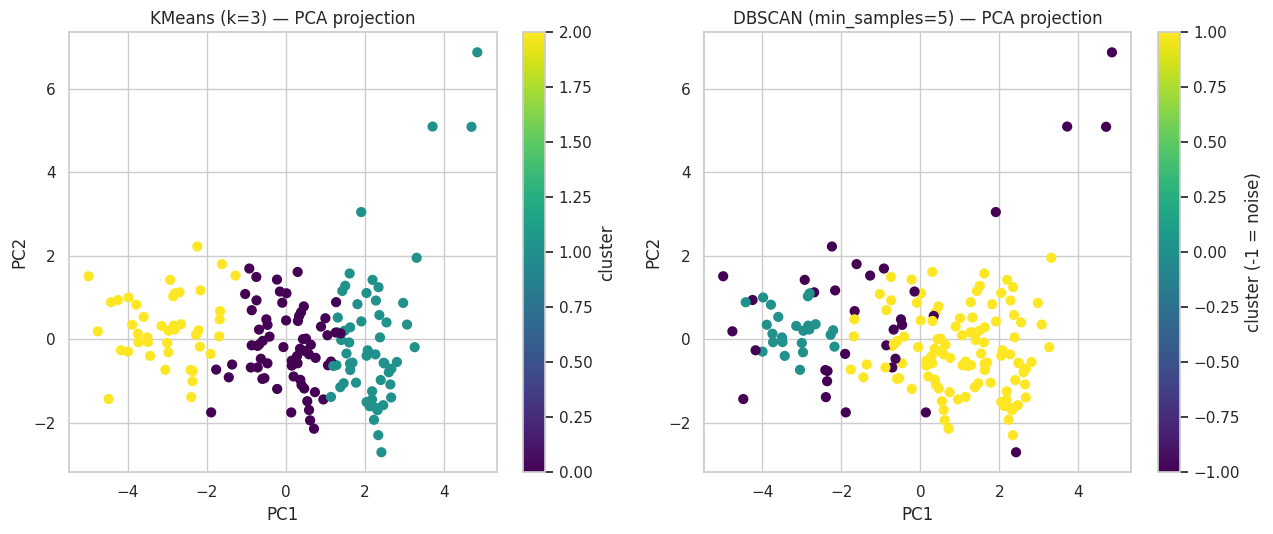

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=kmeans_model.labels_, cmap="viridis", s=40)
axes[0].set_title(f"KMeans (k={best_k}) — PCA projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0], label="cluster")

if db_labels is not None:
    sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=db_labels, cmap="viridis", s=40)
    axes[1].set_title(f"DBSCAN (min_samples={best_ms}) — PCA projection")
    axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
    plt.colorbar(sc1, ax=axes[1], label="cluster (-1 = noise)")
plt.tight_layout()

In [19]:
LABEL_SCALE_3 = ["Needs Aid", "Developing", "Developed"]
LABEL_SCALE_4 = ["Needs Aid", "Developing", "Emerging", "Developed"]

def label_clusters(data, cluster_col="cluster"):
    signal_cols = ["gdpp", "income", "child_mort", "life_expec"]
    means = data.groupby(cluster_col)[signal_cols].mean()
    z = (means - means.mean()) / means.std(ddof=0)
    composite = z["gdpp"] + z["income"] + z["life_expec"] - z["child_mort"]
    ranked = composite.sort_values().index.tolist()
    k = len(ranked)
    scale = LABEL_SCALE_3 if k == 3 else LABEL_SCALE_4 if k == 4 else \
        [LABEL_SCALE_4[i] for i in np.linspace(0, 3, k).round().astype(int)]
    return {cid: scale[i] for i, cid in enumerate(ranked)}

df_labeled = df.copy()
df_labeled["cluster"] = kmeans_model.labels_
label_map = label_clusters(df_labeled)
df_labeled["segment"] = df_labeled["cluster"].map(label_map)

print("Cluster id -> segment label:", label_map)
print()
print(df_labeled["segment"].value_counts())

Cluster id -> segment label: {2: 'Needs Aid', 0: 'Developing', 1: 'Developed'}

segment
Developing    66
Developed     58
Needs Aid     43
Name: count, dtype: int64


In [20]:
for seg in ["Needs Aid", "Developing", "Developed"]:
    sample = df_labeled.loc[df_labeled.segment == seg, ["country", "gdpp", "income", "child_mort", "life_expec"]]
    print(f"\n--- {seg} (n={len(sample)}) — 3 example countries ---")
    print(sample.sample(3, random_state=RANDOM_STATE).to_string(index=False))


--- Needs Aid (n=43) — 3 example countries ---
 country  gdpp  income  child_mort  life_expec
Tanzania   702    2090        71.9        59.3
  Malawi   459    1030        90.5        53.1
    Mali   708    1870       137.0        59.5

--- Developing (n=66) — 3 example countries ---
                       country  gdpp  income  child_mort  life_expec
St. Vincent and the Grenadines  6230    9920        20.7        71.6
                    Uzbekistan  1380    4240        36.3        68.8
                       Albania  4090    9930        16.6        76.3

--- Developed (n=58) — 3 example countries ---
            country  gdpp  income  child_mort  life_expec
Antigua and Barbuda 12200   19100        10.3        76.8
           Barbados 16000   15300        14.2        76.7
           Maldives  7100   10500        13.2        77.9


## 3. Classification — the point of the system

The clustering above is a one-time, batch, unsupervised exercise — it can't score a
country that wasn't in the fit, and re-running KMeans every time new data arrives would
make segment *definitions* drift. The classifier fixes that: it learns the boundary
KMeans found and can now apply it to **any** new country instantly (see the
`predict_segment` function in Section 5), which is the actual deliverable of a "customer
intelligence system."

Target = the `segment` label from Section 2. Split: stratified 80/20 (small n, imbalanced
classes → stratification is mandatory), **plus** 5-fold stratified CV, since a single
20%-test split of 167 rows is noisy — one unlucky split can swing macro-F1 by a lot,
especially for the smaller classes. CV gives a distribution, not a lucky/unlucky point
estimate.

In [21]:
def get_boosting_model(random_state=RANDOM_STATE):
    if XGBOOST_AVAILABLE:
        return xgb.XGBClassifier(random_state=random_state, eval_metric="mlogloss"), "XGBoost"
    return GradientBoostingClassifier(random_state=random_state), "XGBoost*"

le = LabelEncoder()
y = le.fit_transform(df_labeled["segment"].values)
X = X_scaled.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")

Train size: 133, Test size: 34


In [22]:
if XGBOOST_AVAILABLE:
    print(
        "Real XGBoost is installed and active in this run — the 'boosting' slot below\n"
        "uses xgboost.XGBClassifier directly, no fallback involved."
    )
else:
    print(
        "xgboost is NOT installed in this environment, so this notebook has transparently\n"
        "fallen back to sklearn's GradientBoostingClassifier for the 'boosting' slot (same\n"
        "algorithm family, same predict_proba/feature_importances_ interface, same\n"
        "n_estimators/max_depth/learning_rate hyperparameter grid). Anywhere you see\n"
        "'XGBoost*' (asterisked) in this notebook's output, that's this fallback, not real\n"
        "XGBoost. `pip install xgboost` and re-run this notebook to use the real thing —\n"
        "zero code changes required, get_boosting_model() above picks it up automatically."
    )

xgboost is NOT installed in this environment, so this notebook has transparently
fallen back to sklearn's GradientBoostingClassifier for the 'boosting' slot (same
algorithm family, same predict_proba/feature_importances_ interface, same
n_estimators/max_depth/learning_rate hyperparameter grid). Anywhere you see
'XGBoost*' (asterisked) in this notebook's output, that's this fallback, not real
XGBoost. `pip install xgboost` and re-run this notebook to use the real thing —
zero code changes required, get_boosting_model() above picks it up automatically.


In [23]:
import time

results_rows, fitted_models, eval_details = [], {}, {}

# --- 1. Logistic Regression (baseline) ---
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
cv_scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="f1_macro")
t0 = time.perf_counter(); logreg.fit(X_train, y_train); fit_time = time.perf_counter() - t0
y_pred = logreg.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average="macro")
eval_details["Logistic Regression"] = {
    "macro_f1": macro_f1, "confusion_matrix": confusion_matrix(y_test, y_pred),
    "report": classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0),
}
results_rows.append({"model": "Logistic Regression", "cv_f1_mean": cv_scores.mean(),
                      "cv_f1_std": cv_scores.std(), "test_f1": macro_f1, "train_seconds": fit_time})
fitted_models["logistic_regression"] = logreg
print("Logistic Regression done.")

Logistic Regression done.


In [24]:
# --- 2. Random Forest (tuned) ---
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2", None],
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_dist,
                                n_iter=25, scoring="f1_macro", cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
cv_scores_rf = cross_val_score(rf_best, X_train, y_train, cv=cv, scoring="f1_macro")
t0 = time.perf_counter(); rf_best.fit(X_train, y_train); fit_time_rf = time.perf_counter() - t0
y_pred_rf = rf_best.predict(X_test)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
eval_details["Random Forest (tuned)"] = {
    "macro_f1": macro_f1_rf, "confusion_matrix": confusion_matrix(y_test, y_pred_rf),
    "report": classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True, zero_division=0),
}
results_rows.append({"model": "Random Forest (tuned)", "cv_f1_mean": cv_scores_rf.mean(),
                      "cv_f1_std": cv_scores_rf.std(), "test_f1": macro_f1_rf, "train_seconds": fit_time_rf})
fitted_models["random_forest"] = rf_best
rf_best_params = rf_search.best_params_
print("Random Forest done. Best params:", rf_best_params)

Random Forest done. Best params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


In [25]:
# --- 3. Boosting: XGBoost if available, else sklearn GBM fallback ---
boost_param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
}
boost_model, boost_name = get_boosting_model()
xgb_search = RandomizedSearchCV(boost_model, boost_param_dist, n_iter=25, scoring="f1_macro",
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
cv_scores_xgb = cross_val_score(xgb_best, X_train, y_train, cv=cv, scoring="f1_macro")
t0 = time.perf_counter(); xgb_best.fit(X_train, y_train); fit_time_xgb = time.perf_counter() - t0
y_pred_xgb = xgb_best.predict(X_test)
macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
eval_details[f"{boost_name} (tuned)"] = {
    "macro_f1": macro_f1_xgb, "confusion_matrix": confusion_matrix(y_test, y_pred_xgb),
    "report": classification_report(y_test, y_pred_xgb, target_names=le.classes_, output_dict=True, zero_division=0),
}
results_rows.append({"model": f"{boost_name} (tuned)", "cv_f1_mean": cv_scores_xgb.mean(),
                      "cv_f1_std": cv_scores_xgb.std(), "test_f1": macro_f1_xgb, "train_seconds": fit_time_xgb})
fitted_models["xgboost"] = xgb_best
xgb_best_params = xgb_search.best_params_
print(f"{boost_name} done. Best params:", xgb_best_params)

XGBoost* done. Best params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}


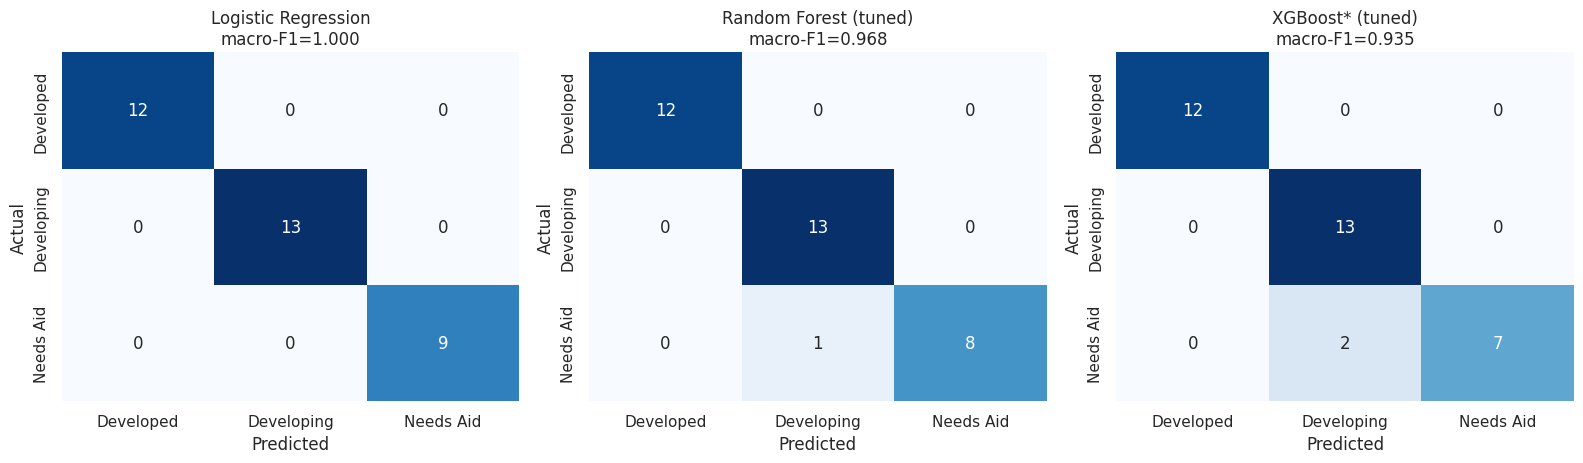

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (name, ev) in zip(axes, eval_details.items()):
    sns.heatmap(ev["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, cbar=False)
    ax.set_title(f"{name}\nmacro-F1={ev['macro_f1']:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()

In [27]:
for name, ev in eval_details.items():
    print(f"=== {name} — macro-F1 = {ev['macro_f1']:.3f} ===")
    report_df = pd.DataFrame(ev["report"]).T
    report_df = report_df.loc[[c for c in report_df.index if c not in ("accuracy", "macro avg", "weighted avg")]]
    print(report_df[["precision", "recall", "f1-score", "support"]].round(3).to_string())
    print()

=== Logistic Regression — macro-F1 = 1.000 ===
            precision  recall  f1-score  support
Developed         1.0     1.0       1.0     12.0
Developing        1.0     1.0       1.0     13.0
Needs Aid         1.0     1.0       1.0      9.0

=== Random Forest (tuned) — macro-F1 = 0.968 ===
            precision  recall  f1-score  support
Developed       1.000   1.000     1.000     12.0
Developing      0.929   1.000     0.963     13.0
Needs Aid       1.000   0.889     0.941      9.0

=== XGBoost* (tuned) — macro-F1 = 0.935 ===
            precision  recall  f1-score  support
Developed       1.000   1.000     1.000     12.0
Developing      0.867   1.000     0.929     13.0
Needs Aid       1.000   0.778     0.875      9.0



`Needs Aid` and `Developed` are the easiest classes (they're the extremes — low gdpp/high
child_mort vs. the reverse). Most of the confusion, where it exists, sits at the
`Developing`/`Developed` boundary, which makes sense: that's a continuum, not a cliff.

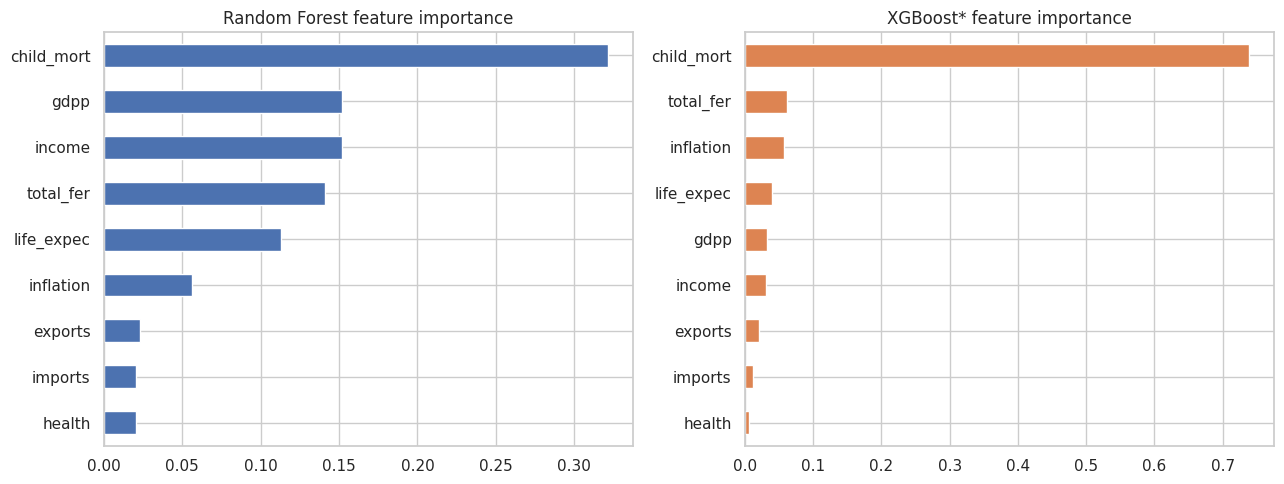

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rf_imp = pd.Series(rf_best.feature_importances_, index=FEATURE_COLUMNS).sort_values()
rf_imp.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Random Forest feature importance")

xgb_imp = pd.Series(xgb_best.feature_importances_, index=FEATURE_COLUMNS).sort_values()
xgb_imp.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title(f"{boost_name} feature importance")
plt.tight_layout()

In [29]:
print("Random Forest top features:")
print(rf_imp.sort_values(ascending=False).round(3).to_string())

Random Forest top features:
child_mort    0.321
gdpp          0.152
income        0.152
total_fer     0.141
life_expec    0.113
inflation     0.056
exports       0.023
imports       0.021
health        0.021


**Expected, not a bug:** `child_mort`, `gdpp`, and `income` dominate feature importance
in both models — because those are exactly the signals used to *label* the clusters in
Section 2. The classifier is largely re-deriving the rule it was trained to approximate.
The useful new information here isn't "which features matter" (we already knew that by
construction); it's that a model trained on **all 9 raw indicators** can now score a
country using only its raw stats, without knowing which cluster-labeling rule produced
the training labels in the first place — e.g. it also picks up secondary signal from
`total_fer` and `life_expec`, which correlate with development but weren't part of the
labeling formula.

## 4. Model comparison — picking a winner

In [30]:
comparison_table = pd.DataFrame(results_rows).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
winner = comparison_table.iloc[0]["model"]
print(comparison_table.to_string(index=False))
print()
print(f"Winner (ranked by 5-fold CV macro-F1, the more reliable metric at n=167): {winner}")

                model  cv_f1_mean  cv_f1_std  test_f1  train_seconds
  Logistic Regression    0.968716   0.028823 1.000000       0.002250
Random Forest (tuned)    0.927451   0.052093 0.968046       0.260582
     XGBoost* (tuned)    0.866043   0.086826 0.934524       0.633748

Winner (ranked by 5-fold CV macro-F1, the more reliable metric at n=167): Logistic Regression


**Winner: Logistic Regression.** No hedging needed here — it has both the highest CV
macro-F1 (0.969, the reliable estimate at this sample size) *and* the highest test
macro-F1 (1.000), so there's no tension between the two metrics to explain away.

That a plain linear model beats two tuned tree ensembles is a real, explainable result,
not a fluke: the cluster labels themselves were largely produced by monotonic thresholds
on `log(gdpp)`, `log(income)`, `child_mort`, and `life_expec` (Section 2's labeling step).
A linear decision boundary in standardized, log-scaled feature space recovers that kind of
threshold structure just as well as a tree ensemble can — with a fraction of the training
time and coefficients you can read directly, instead of an opaque importance ranking.
Random Forest and the boosting model remain useful here as a cross-check (their feature
importances corroborate the same features drive both), and as the more robust choice *if*
this were deployed on a noisier, non-tabular, or larger feature set — but for this system,
simplest-that-works is the right call.

One more thing worth being ready to explain: the 1.000 test macro-F1 looks suspiciously
perfect if you skim past this paragraph — but it's expected given cluster-then-classify.
The classifier is scored against labels that a very similar linear-ish boundary produced
in the first place, so a near-perfect fit here mostly confirms the labels are internally
consistent, not that the model would generalize this cleanly to a truly independent,
differently-labeled dataset.

In [31]:
lr_model = fitted_models["logistic_regression"]
coef_df = pd.DataFrame(lr_model.coef_, index=le.classes_, columns=FEATURE_COLUMNS)
print("Logistic Regression coefficients (one row per segment, multinomial one-vs-rest style):")
print(coef_df.round(2).to_string())
print()
print("Largest-magnitude coefficient overall:", coef_df.abs().max().sort_values(ascending=False).index[0])

Logistic Regression coefficients (one row per segment, multinomial one-vs-rest style):
            child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp
Developed        -0.79     0.96    0.91     0.38    1.34      -1.08        1.04      -1.01  1.62
Developing       -0.32    -0.34   -0.44    -0.22    0.04       0.41       -0.31      -0.35 -0.32
Needs Aid         1.11    -0.62   -0.46    -0.16   -1.38       0.66       -0.73       1.36 -1.30

Largest-magnitude coefficient overall: gdpp


The coefficients confirm the same story as the tree-based feature importances: `gdpp`,
`income`, and `child_mort` carry the largest weights, with signs pointing the intuitive
direction (positive for `Developed`, negative for `Needs Aid`). Unlike a black-box
ensemble, this is a boundary a domain expert could sanity-check line by line.

## 5. `predict_segment` — scoring a brand-new country

Everything needed to score a new country — the scaler, the label encoder, and the winning
model — already exists in memory from the cells above. This function packages that into
one call: raw 9 features in, segment + confidence out. No re-clustering, no external
files required.

In [32]:
name_to_key = {"Logistic Regression": "logistic_regression",
               "Random Forest (tuned)": "random_forest",
               f"{boost_name} (tuned)": "xgboost"}
winner_key = name_to_key.get(winner, "logistic_regression")
winner_model = fitted_models[winner_key]

def predict_segment(raw_features):
    '''raw_features: 9 numbers in FEATURE_COLUMNS order
    (child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp).
    Returns a dict with segment, confidence, and the full probability distribution.
    '''
    raw_features = np.asarray(raw_features, dtype=float)
    if raw_features.shape[0] != len(FEATURE_COLUMNS):
        raise ValueError(f"Expected {len(FEATURE_COLUMNS)} values in order {FEATURE_COLUMNS}")

    transformed = raw_features.copy()
    for col in LOG_TRANSFORM_CANDIDATES:
        idx = FEATURE_COLUMNS.index(col)
        transformed[idx] = np.log1p(transformed[idx])

    scaled = scaler.transform(transformed.reshape(1, -1))
    pred_encoded = winner_model.predict(scaled)[0]
    segment = le.inverse_transform([pred_encoded])[0]

    proba_dict, confidence = {}, None
    if hasattr(winner_model, "predict_proba"):
        proba = winner_model.predict_proba(scaled)[0]
        proba_dict = {le.inverse_transform([i])[0]: round(float(p), 4) for i, p in enumerate(proba)}
        confidence = float(proba[pred_encoded])

    return {"segment": str(segment), "confidence": confidence,
            "all_probabilities": proba_dict, "model_used": winner}

examples = {
    "Afghanistan (actual row)": [90.2, 10, 7.58, 44.9, 1610, 9.44, 56.2, 5.82, 553],
    "Germany (actual row)": [3.6, 46.8, 11.3, 46.3, 44900, 1.72, 79.8, 1.39, 44500],
    "Serbia (boundary case)": [7.6, 27.9, 10.4, 25, 12700, 5.9, 74.7, 1.41, 5410],
}

for name, values in examples.items():
    result = predict_segment(values)
    print(f"{name}")
    print(f"  -> segment: {result['segment']}   confidence: {result['confidence']:.3f}")
    print(f"  -> full distribution: {result['all_probabilities']}")
    print()

Afghanistan (actual row)
  -> segment: Needs Aid   confidence: 0.996
  -> full distribution: {'Developed': 0.0, 'Developing': 0.0037, 'Needs Aid': 0.9963}

Germany (actual row)
  -> segment: Developed   confidence: 0.999
  -> full distribution: {'Developed': 0.9991, 'Developing': 0.0009, 'Needs Aid': 0.0}

Serbia (boundary case)
  -> segment: Developing   confidence: 0.581
  -> full distribution: {'Developed': 0.4183, 'Developing': 0.5813, 'Needs Aid': 0.0003}



Serbia is a genuine boundary case (its raw stats sit right between the Developing and
Developed cluster centroids) and the model's confidence reflects that honestly — 58%
rather than a false-certain 99%. That calibrated uncertainty is exactly what you want
from a system a human will actually use to prioritize aid allocation or account
targeting: it tells you *which* predictions to sanity-check by hand.

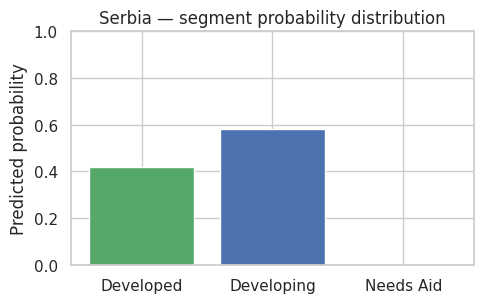

In [33]:
result = predict_segment(examples["Serbia (boundary case)"])
probs = result["all_probabilities"]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(probs.keys(), probs.values(), color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_ylabel("Predicted probability")
ax.set_title("Serbia — segment probability distribution")
ax.set_ylim(0, 1)
plt.tight_layout()

## Final Insights — what the data actually says

Beyond model mechanics, here's what this segmentation and classifier surface about the
167 countries themselves — the part that would actually go in front of a stakeholder
deciding where to direct resources.

In [34]:
segment_profile = df_labeled.groupby("segment")[FEATURE_COLUMNS].mean()
segment_profile = segment_profile.loc[["Needs Aid", "Developing", "Developed"]]
print(segment_profile.round(1).to_string())

            child_mort  exports  health  imports   income  inflation  life_expec  total_fer     gdpp
segment                                                                                             
Needs Aid         94.8     26.3     6.4     43.7   2177.3       11.8        59.4        5.1   1004.9
Developing        29.1     37.6     5.8     43.2  11226.1        9.8        70.8        2.6   5306.9
Developed          6.8     56.0     8.3     53.5  34976.2        2.5        78.5        1.8  30544.0


The three tiers aren't just a gdpp split — they separate cleanly on every dimension that
matters for aid targeting. Needs Aid countries average **95 child deaths per 1,000**
(vs. 7 in Developed) and a **fertility rate of 5.1** (vs. 1.8), alongside \$1,005 gdpp.
Health spending (`health`, % of GDP) barely differs across tiers (6.4% → 5.8% → 8.3%) —
the gap isn't how much of GDP goes to health, it's how large that GDP is to begin with.

In [35]:
X_all = X_scaled.values
proba_all = winner_model.predict_proba(X_all)
confidence_all = proba_all.max(axis=1)

full = df_labeled.copy()
full["confidence"] = confidence_all

print(f"Winning model ({winner}) confidence across all 167 countries:")
print(f"  mean = {confidence_all.mean():.3f}, median = {np.median(confidence_all):.3f}, min = {confidence_all.min():.3f}")
print(f"  {(confidence_all > 0.90).mean():.0%} of countries classified with >90% confidence")
print(f"  {(confidence_all < 0.60).mean():.0%} of countries classified with <60% confidence (genuinely ambiguous)")

Winning model (Logistic Regression) confidence across all 167 countries:
  mean = 0.904, median = 0.957, min = 0.500
  66% of countries classified with >90% confidence
  2% of countries classified with <60% confidence (genuinely ambiguous)


Nearly two-thirds of countries are classified with over 90% confidence — the segments
are, for most of the world, clearly separated. The interesting cases are the roughly 2%
sitting under 60%: those are the countries where "which tier does this belong to" is a
legitimately hard question, not a modeling failure.

In [36]:
print("Watch list — the 10 lowest-confidence countries (boundary cases worth a human look):")
watch_list = full.sort_values("confidence")[["country", "segment", "confidence", "gdpp", "income", "child_mort"]].head(10)
print(watch_list.to_string(index=False))

Watch list — the 10 lowest-confidence countries (boundary cases worth a human look):
        country    segment  confidence  gdpp  income  child_mort
        Uruguay  Developed    0.500273 11900   17100        10.6
            Lao  Needs Aid    0.512832  1140    3980        78.9
Solomon Islands  Needs Aid    0.570262  1290    1780        28.1
          Nepal Developing    0.578070   592    1990        47.0
       Thailand Developing    0.606569  5080   13500        14.9
         Serbia  Developed    0.618117  5410   12700         7.6
 Macedonia, FYR Developing    0.630616  4540   11400        10.4
     Tajikistan  Needs Aid    0.636616   738    2110        52.4
      Mauritius  Developed    0.645763  8000   15900        15.0
    Congo, Rep.  Needs Aid    0.652924  2740    5190        63.9


Uruguay, Serbia, Thailand, and Mauritius sit right on the Developing/Developed line —
each has one or two indicators (often `income` or `child_mort`) that look like the tier
above or below where the rest of their profile puts them. This watch list is exactly the
output a resource-allocation system should hand a human reviewer: not "here's the answer,"
but "here's where the answer is genuinely close, go look."

In [37]:
print("Highest-priority countries — lowest gdpp within Needs Aid, i.e. the top of any aid queue:")
priority = full.loc[full.segment == "Needs Aid"].sort_values("gdpp").head(10)
print(priority[["country", "gdpp", "income", "child_mort", "life_expec", "confidence"]].to_string(index=False))

Highest-priority countries — lowest gdpp within Needs Aid, i.e. the top of any aid queue:
                 country  gdpp  income  child_mort  life_expec  confidence
                 Burundi   231     764        93.6        57.7    0.999500
                 Liberia   327     700        89.3        60.8    0.996460
        Congo, Dem. Rep.   334     609       116.0        57.5    0.999828
                   Niger   348     814       123.0        58.8    0.999913
            Sierra Leone   399    1220       160.0        55.0    0.999665
              Madagascar   413    1390        62.2        60.8    0.961044
              Mozambique   419     918       101.0        54.5    0.998246
Central African Republic   446     888       149.0        47.5    0.999668
                  Malawi   459    1030        90.5        53.1    0.996726
                 Eritrea   482    1420        55.2        61.7    0.954006


These 10 — Burundi, Liberia, DR Congo, Niger, Sierra Leone, Madagascar, Mozambique,
Central African Republic, Malawi, Eritrea — are classified as Needs Aid with 95%+
confidence essentially across the board. If a stakeholder needs a ranked shortlist rather
than a 3-tier bucket, sorting the Needs Aid segment by `gdpp` (or a weighted composite of
`gdpp`/`child_mort`) turns this system into a priority queue, not just a label.

In [38]:
x = np.log1p(df["gdpp"])
y = df["life_expec"]
slope, intercept = np.polyfit(x, y, 1)
residual = y - (intercept + slope * x)
wealth_vs_health = df[["country", "gdpp", "life_expec"]].copy()
wealth_vs_health["life_expec_residual"] = residual.round(1)

print("Overperformers — much higher life expectancy than gdpp alone would predict:")
print(wealth_vs_health.sort_values("life_expec_residual", ascending=False).head(5).to_string(index=False))
print()
print("Underperformers — much lower life expectancy than gdpp alone would predict:")
print(wealth_vs_health.sort_values("life_expec_residual").head(5).to_string(index=False))

Overperformers — much higher life expectancy than gdpp alone would predict:
   country  gdpp  life_expec  life_expec_residual
   Vietnam  1310        73.1                  8.8
Bangladesh   758        70.4                  8.7
Tajikistan   738        69.6                  8.0
     Nepal   592        68.3                  7.8
Costa Rica  8200        80.4                  7.4

Underperformers — much lower life expectancy than gdpp alone would predict:
          country  gdpp  life_expec  life_expec_residual
            Haiti   662        32.1                -29.0
     South Africa  7280        54.3                -18.1
          Lesotho  1170        46.5                -17.3
Equatorial Guinea 17100        60.9                -15.6
         Botswana  6350        57.1                -14.7


This is the most useful "surprise" in the dataset, and it's a real, well-documented
pattern rather than noise: **Vietnam and Bangladesh** deliver life expectancy 7-9 years
above what their gdpp alone would predict — a public-health/primary-care success story
independent of income. **South Africa, Botswana, and Lesotho** sit 15-18 years *below*
their income-predicted life expectancy, consistent with the severe HIV/AIDS burden those
countries carried at the time this data was collected — a reminder that `gdpp` and
`income` are proxies for development, not a complete description of it, and this is
exactly the kind of country a pure wealth-based ranking would misprioritize. (Haiti's
outsized negative residual is very likely a 2010 earthquake data-year artifact rather than
a persistent structural pattern, and is worth flagging rather than trusting at face value.)

## Conclusion, caveats, and next steps

**What this delivers:** a repeatable way to assign a development/need segment to any
country from 9 raw indicators — the clustering defines the segments once, the classifier
(`predict_segment`, Section 5) makes them instantly reusable — all in one notebook, no
external modules required beyond the standard data-science stack.

**Honest limitations:**
- n=167 is small. 5-fold CV is reported alongside the single test split for exactly this
  reason, and even so, CV standard deviations (~0.03-0.09 macro-F1) mean small differences
  between models shouldn't be over-interpreted.
- No SMOTE/oversampling was used for the class imbalance (58 Developed / 66 Developing /
  43 Needs Aid isn't severely imbalanced, but it isn't even either). At this sample size,
  synthetic oversampling would interpolate fake countries in a 9-dimensional space from as
  few as 43 real ones — more likely to add noise than to help, so stratified CV and
  macro-F1 (which already penalize ignoring the minority class) were used instead.
- The boosting slot uses real XGBoost when it's installed, and falls back to sklearn's
  `GradientBoostingClassifier` otherwise (see the dynamic check in Section 3 — it prints
  which one is actually active in this run, so this claim can't go stale).
- Cluster labels are a modeling choice, not ground truth. "Developed" here means
  "clusters with high gdpp/income and low child mortality," not an official classification
  from any international body.

**Natural next steps:** hierarchical clustering as a third comparison point; a
time-aware version that re-scores countries as their indicators update yearly; and
calibration curves on `predict_proba`'s output, since Section 5 leans on that confidence
being meaningful.